In [2]:
# Cell 1: Imports and setup
import os
from dotenv import load_dotenv
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

load_dotenv("../.env")
API_KEY = os.getenv("APCA_API_KEY_ID")
SECRET_KEY = os.getenv("APCA_API_SECRET_KEY")

In [3]:
# Cell 2: Fetch data
client = StockHistoricalDataClient(API_KEY, SECRET_KEY)

end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=180)

request_params = StockBarsRequest(
    symbol_or_symbols=["AAPL"],  # requesting only one symbol
    timeframe=TimeFrame.Day,
    start=start_date,
    end=end_date
)

bars = client.get_stock_bars(request_params).df

data = bars.copy()

# Fix the MultiIndex (symbol, timestamp) to just timestamp
data = data.reset_index()  # Flattens the index so 'timestamp' becomes a column
data = data[data['symbol'] == 'AAPL']  # Filter for AAPL if multiple symbols
data = data.set_index('timestamp')     # Set datetime as index

# Ensure proper dtypes
data = data.sort_index()
data['close'] = data['close'].astype(float)

In [4]:
# Cell 3: Calculate RSI
delta = data['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

window = 14
avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()
epsilon = 1e-10
rs = avg_gain / (avg_loss + epsilon)
data['RSI'] = 100 - (100 / (1 + rs))

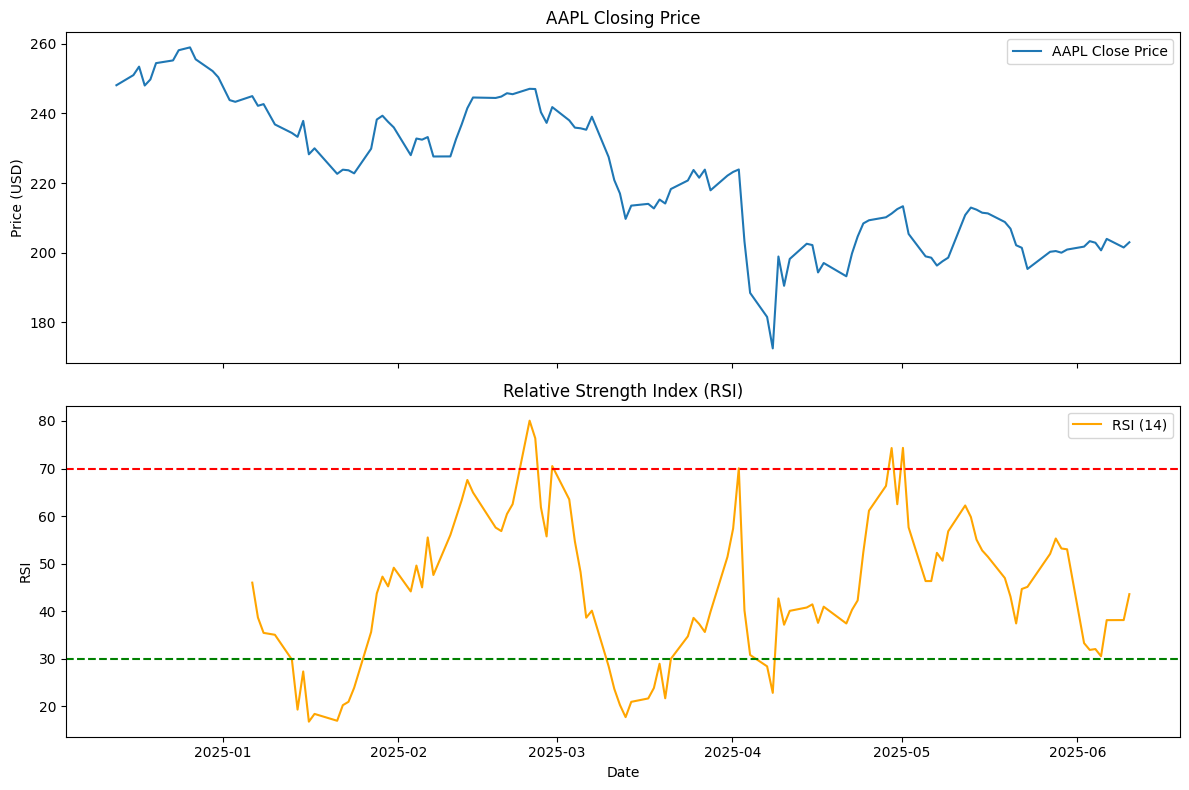

In [5]:
# Cell 4: Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(data.index, data['close'], label='AAPL Close Price')
ax1.set_title("AAPL Closing Price")
ax1.set_ylabel("Price (USD)")
ax1.legend()

ax2.plot(data.index, data['RSI'], label='RSI (14)', color='orange')
ax2.axhline(70, color='red', linestyle='--')
ax2.axhline(30, color='green', linestyle='--')
ax2.set_title("Relative Strength Index (RSI)")
ax2.set_ylabel("RSI")
ax2.set_xlabel("Date")
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
data['position'] = 0  # 0 = no position, 1 = long

for i in range(1, len(data)):
    if data['RSI'].iloc[i-1] < 30 and data['RSI'].iloc[i] > 30:
        data.loc[data.index[i], 'position'] = 1  # Buy
    elif data['RSI'].iloc[i-1] > 70 and data['RSI'].iloc[i] < 70:
        data.loc[data.index[i], 'position'] = 0  # Sell
    else:
        data.loc[data.index[i], 'position'] = data.loc[data.index[i-1], 'position']  # Hold